
>>> Rebuilding kick sample...
[######------------------------] 20%  stage 1/5
[############------------------] 40%  stage 2/5
[##################------------] 60%  stage 3/5
[########################------] 80%  stage 4/5
[##############################] 100%  stage 5/5

SUCCESS ✅  Kick rebuilt and saved at:
/Users/yerik/Downloads/__DRUM_SAMPLE_TEST/_kicks/test_kick_01_rebuild.wav



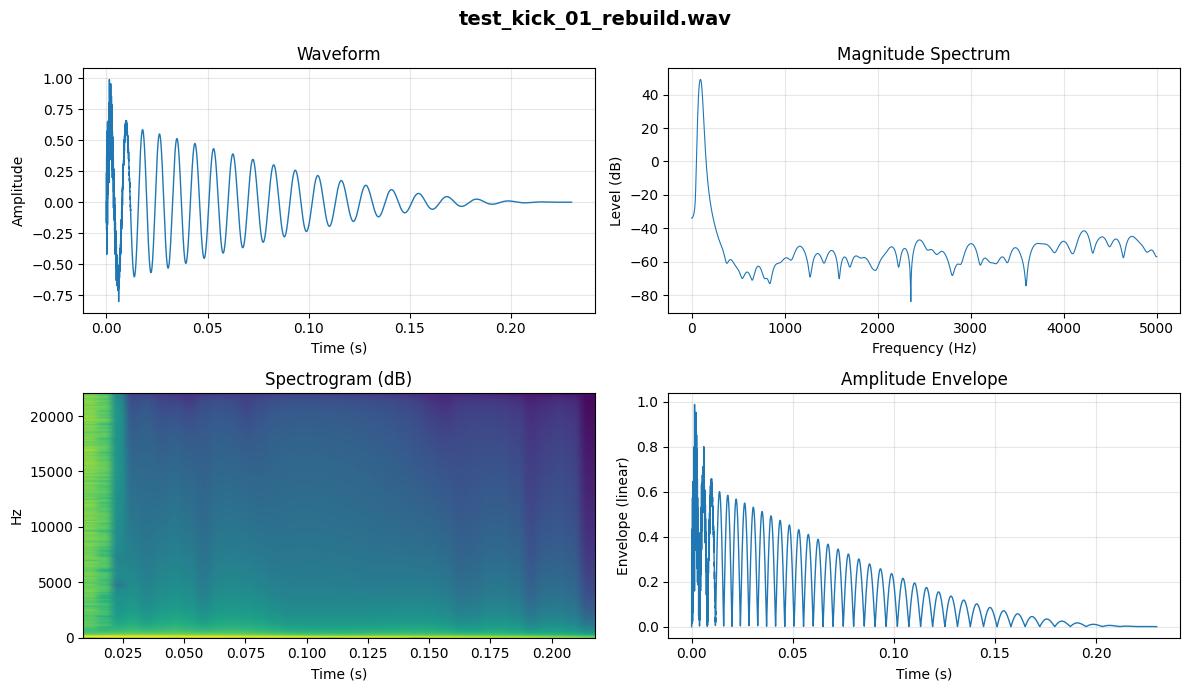

/Users/yerik/Downloads/__DRUM_SAMPLE_TEST/_kicks/test_kick_01_rebuild.wav


In [3]:
# Example usage in your Jupyter / script:

out_root = "/Users/yerik/Downloads/__DRUM_SAMPLE_TEST/_kicks"

kick, sr, out_file = _kick_0911_rebuild_GET_wav(
    out_path=out_root,
    file_name="test_kick_01_rebuild.wav",
    sr=44100,
    duration=0.230,
    f_start=130.0,
    f_end=55.0,
    peak_dbfs=-0.1,
    noise_level=0.30,
    plot_dashboard=True  # set False if you only want the audio
)

print(out_file)


In [2]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt


# -----######-----######-----######-----######-----
#   CORE FUNCTION – KICK SYNTH REBUILD
# -----######-----######-----######-----######-----

def _kick_0911_rebuild_GET_wav(out_path,
                               file_name="test_kick_01_rebuild.wav",
                               sr=44100,
                               duration=0.230,
                               f_start=130.0,
                               f_end=55.0,
                               peak_dbfs=-0.1,
                               noise_level=0.30,
                               plot_dashboard=True):
    """
    Rebuilds a synthetic kick sample similar to the reference plot and
    saves it as a high-quality 24-bit WAV.

    Parameters
    ----------
    out_path : str
        Folder where the WAV will be saved.
    file_name : str
        Name of the output file.
    sr : int
        Sample rate (Hz).
    duration : float
        Duration in seconds (≈0.23 according to the image).
    f_start : float
        Initial frequency of the pitch sweep (Hz).
    f_end : float
        Final frequency of the pitch sweep (Hz).
    peak_dbfs : float
        Target peak level in dBFS (0 dBFS = full scale).
    noise_level : float
        Relative level of the high-frequency transient click.
    plot_dashboard : bool
        If True, shows a quick dashboard with waveform, spectrum,
        spectrogram and envelope (similar to your screenshot).
    """

    # ================= TQM BAR (mini progress) =================
    def _tqm_print(stage, total=5, bar_len=30):
        filled = int(bar_len * stage / float(total))
        bar = "#" * filled + "-" * (bar_len - filled)
        print(f"[{bar}] {int(100 * stage / float(total))}%  stage {stage}/{total}")

    print("\n>>> Rebuilding kick sample...")
    _tqm_print(1)

    # ---------- Time base ----------
    n_samples = int(duration * sr)
    t = np.linspace(0.0, duration, n_samples, endpoint=False)

    # ---------- Pitch envelope: exponential sweep ----------
    # f(t) = f_start * (k ** (t/dur)), where k = f_end/f_start
    k = f_end / float(f_start)
    inst_phase = 2.0 * np.pi * f_start * duration / np.log(k) * (k ** (t / duration) - 1.0)
    sine_tail = np.sin(inst_phase)

    _tqm_print(2)

    # ---------- Amplitude envelope ----------
    # Fast attack (~0.7 ms) + exponential decay (~190 ms)
    attack_time = 0.0007
    decay_time = 0.190

    env = np.zeros_like(t)
    attack_samples = max(1, int(attack_time * sr))

    # Linear attack
    env[:attack_samples] = np.linspace(0.0, 1.0, attack_samples)

    # Exponential decay after attack
    t_decay = t[attack_samples:] - t[attack_samples]
    env[attack_samples:] = np.exp(-t_decay / decay_time)

    # Ensure no click at end
    env *= np.hanning(len(env) * 2)[len(env):]

    # ---------- Transient click (noise burst with fast decay) ----------
    noise = np.random.randn(len(t))
    click_env = np.exp(-t / 0.004)  # super short
    click_env[t > 0.012] = 0.0      # about 12 ms long
    transient = noise * click_env

    # Emphasize high frequencies of transient (simple differentiator)
    transient_hp = np.concatenate([[0.0], transient[1:] - transient[:-1]])

    _tqm_print(3)

    # ---------- Combine layers ----------
    kick = sine_tail * env + noise_level * transient_hp

    # ---------- Normalize to target peak ----------
    peak_lin = 10.0 ** (peak_dbfs / 20.0)  # e.g. -0.1 dBFS
    current_peak = np.max(np.abs(kick)) + 1e-12
    kick = kick * (peak_lin / current_peak)

    _tqm_print(4)

    # ---------- Export as 24-bit WAV ----------
    out_full = out_path.rstrip("/") + "/" + file_name
    sf.write(out_full, kick.astype(np.float32), sr, subtype="PCM_24")

    _tqm_print(5)
    print(f"\nSUCCESS ✅  Kick rebuilt and saved at:\n{out_full}\n")

    # ---------- Optional dashboard ----------
    if plot_dashboard:
        fig = plt.figure(figsize=(12, 7))
        fig.suptitle(file_name, fontsize=14, fontweight="bold")

        # Waveform
        ax1 = plt.subplot(2, 2, 1)
        ax1.plot(t, kick, linewidth=1.0)
        ax1.set_title("Waveform")
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Amplitude")
        ax1.grid(alpha=0.3)

        # Magnitude spectrum (to 5 kHz)
        ax2 = plt.subplot(2, 2, 2)
        freqs = np.fft.rfftfreq(len(kick), 1.0 / sr)
        spec = np.fft.rfft(kick * np.hanning(len(kick)))
        mag_db = 20.0 * np.log10(np.abs(spec) + 1e-12)
        mask_5k = freqs <= 5000
        ax2.plot(freqs[mask_5k], mag_db[mask_5k], linewidth=0.8)
        ax2.set_title("Magnitude Spectrum")
        ax2.set_xlabel("Frequency (Hz)")
        ax2.set_ylabel("Level (dB)")
        ax2.grid(alpha=0.3)

        # Spectrogram
        ax3 = plt.subplot(2, 2, 3)
        nfft = 1024
        hop = nfft // 4
        Pxx, freqs_s, bins_s, im = ax3.specgram(
            kick,
            NFFT=nfft,
            Fs=sr,
            noverlap=nfft - hop,
            mode="psd",
            scale="dB"
        )
        ax3.set_ylim(0, 22050)
        ax3.set_title("Spectrogram (dB)")
        ax3.set_xlabel("Time (s)")
        ax3.set_ylabel("Hz")

        # Amplitude envelope
        ax4 = plt.subplot(2, 2, 4)
        ax4.plot(t, np.abs(kick), linewidth=1.0)
        ax4.set_title("Amplitude Envelope")
        ax4.set_xlabel("Time (s)")
        ax4.set_ylabel("Envelope (linear)")
        ax4.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return kick, sr, out_full
